In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [5]:
dataframe = pd.read_csv('../assets/seeds_11/train_11.csv')
dataframe.head()
dataframe.info()
dataframe.describe()

<class 'pandas.DataFrame'>
RangeIndex: 87447 entries, 0 to 87446
Columns: 514 entries, Unnamed: 0 to label
dtypes: float64(512), int64(2)
memory usage: 342.9 MB


,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,503,504,505,506,507,508,509,510,511,label
count,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,...,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000
mean,54758.958020,0.679764,0.849554,0.445289,2.223606,0.402982,0.150932,0.787322,0.950320,1.445799,...,1.291778,0.069529,1.362511,0.855332,0.747545,0.792669,0.943633,1.012457,1.951236,1.678731
std,31526.549025,0.536190,0.469740,0.377183,0.651790,0.390675,0.247751,0.378588,0.581192,0.565572,...,0.647184,0.128277,0.751653,0.431239,0.547470,0.443908,0.750329,0.491377,0.821838,1.357813
min,0.000000,0.000000,0.000000,0.000000,0.091206,0.000000,0.000000,0.000000,0.000000,0.007696,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27479.500000,0.249447,0.493474,0.141849,1.773298,0.123679,0.001104,0.515237,0.516021,1.033248,...,0.807376,0.000866,0.818487,0.536350,0.331734,0.466622,0.358371,0.652813,1.370411,0.000000
50%,54766.000000,0.569162,0.814180,0.364473,2.215324,0.297666,0.040499,0.760290,0.884864,1.406150,...,1.232063,0.020850,1.254919,0.789990,0.645979,0.717027,0.770772,0.968429,1.942684,2.000000
75%,82038.500000,0.996849,1.155845,0.659865,2.653792,0.559518,0.190120,1.021999,1.302694,1.811211,...,1.714781,0.079786,1.779154,1.105982,1.044386,1.040224,1.353090,1.318304,2.511128,3.000000
max,109308.000000,4.149904,3.961852,3.237006,5.986111,4.305758,2.643863,3.651450,4.827925,4.069973,...,4.894304,2.531964,5.641622,3.502565,4.887534,3.861927,5.971847,4.277090,5.901646,3.000000


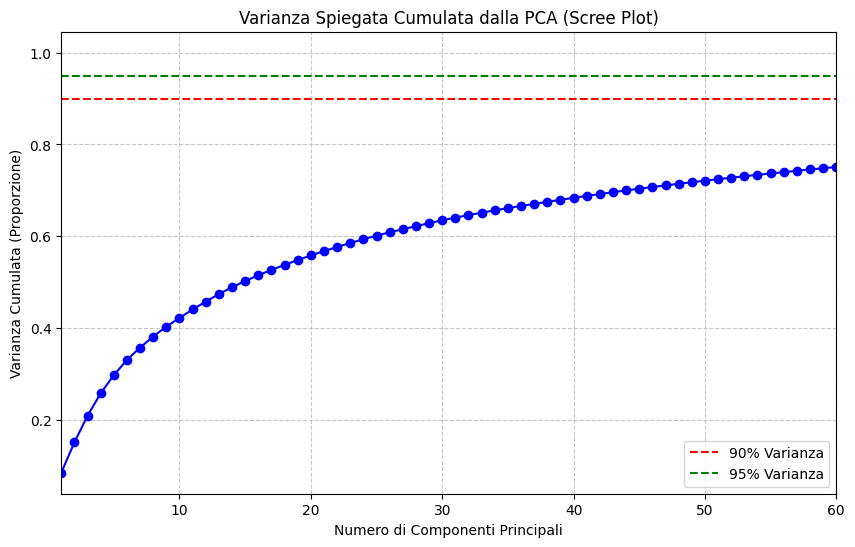

In [6]:
# 1. Standardizzazione
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(dataframe)

# 2. Inizializza la PCA SENZA specificare il numero di componenti.
# In questo modo calcolerà tutte le 512 componenti (o min(n_samples, n_features)).
pca = PCA()
pca.fit(X_train_scaled)

# 3. Estrai la proporzione di varianza spiegata da ogni singola componente
# e calcola la somma cumulativa
varianza_singola = pca.explained_variance_ratio_
varianza_cumulata = np.cumsum(varianza_singola)

# 4. Creazione del Grafico (Scree Plot)
plt.figure(figsize=(10, 6))

# Plotta la curva della varianza cumulata
plt.plot(range(1, len(varianza_cumulata) + 1), varianza_cumulata, marker='o', linestyle='-', color='b')
plt.xlim(1, 60)

# Aggiungi linee di riferimento (es. per il 90% e il 95% della varianza)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Varianza')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% Varianza')

# Estetica del grafico
plt.title('Varianza Spiegata Cumulata dalla PCA (Scree Plot)')
plt.xlabel('Numero di Componenti Principali')
plt.ylabel('Varianza Cumulata (Proporzione)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right')

In [7]:
PCA_32 = PCA(n_components=32)
X_train_pca_32 = PCA_32.fit_transform(X_train_scaled)
print(f'Varianza spiegata con 32 componenti: {PCA_32.explained_variance_ratio_.sum():.4f}')


Varianza spiegata con 32 componenti: 0.6459


In [8]:
PCA_16 = PCA(n_components=16)
X_train_pca_16 = PCA_16.fit_transform(X_train_scaled)
print(f'Varianza spiegata con 16 componenti: {PCA_16.explained_variance_ratio_.sum():.4f}')


Varianza spiegata con 16 componenti: 0.5149


In [9]:
PCA_8 = PCA(n_components=8)
X_train_pca_8 = PCA_8.fit_transform(X_train_scaled)
print(f'Varianza spiegata con 8 componenti: {PCA_8.explained_variance_ratio_.sum():.4f}')


Varianza spiegata con 8 componenti: 0.3811


In [10]:
PCA_4 = PCA(n_components=4)
X_train_pca_4 = PCA_4.fit_transform(X_train_scaled)
print(f'Varianza spiegata con 4 componenti: {PCA_4.explained_variance_ratio_.sum():.4f}')


Varianza spiegata con 4 componenti: 0.2574
